<>:67: SyntaxWarning: invalid escape sequence '\s'
<>:70: SyntaxWarning: invalid escape sequence '\s'
<>:67: SyntaxWarning: invalid escape sequence '\s'
<>:70: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_12974/2198782983.py:67: SyntaxWarning: invalid escape sequence '\s'
  df1 = pd.read_csv("FI_time_resolved_N6_ratio0.25.dat", sep='\s+', header=None)
/tmp/ipykernel_12974/2198782983.py:70: SyntaxWarning: invalid escape sequence '\s'
  df2 = pd.read_csv("FI_time_resolved_N6_ratio4.dat", sep='\s+', header=None)


Currently running N =  6


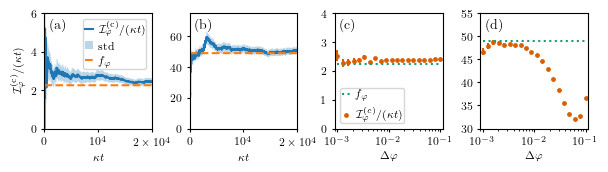

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import qutip as qt
import numpy as np
from scipy.sparse.linalg import eigs
from scipy.sparse import csr_matrix
from pathlib import Path
import matplotlib as mpl
from matplotlib import rc
rc('text', usetex=True)
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = "STIX"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["legend.borderpad"] = 0.15
mpl.rcParams["font.size"] = 8
colors=['#1b9e77','#d95f02','#7570b3']
#------------------------------------------------------------------------------#
ratios=[4, 0.25] # omega/omega_c values to iterate over
Ns=[6] # system sizes to iterate over
#------------------------------------------------------------------------------#
QFI = np.array([np.zeros(3)]) #initialize array to store data, each row
                                #corresponds to [N, omega/omega_c, QFI]
#------------------------------------------------------------------------------#
for N in Ns: # iterate over system sizes
    print('Currently running N = ', N)
    # system parameterss
    ddphi = 5*10**(-5) # small increment for phase shift for numerical derivatives
    omega_c = N/2 # critical frequency for given system size N
    # Collective spin operators for the sensor
    S_x = qt.jmat(N/2, 'x')
    S_y = qt.jmat(N/2, 'y')
    S_z = qt.jmat(N/2, 'z')
    S_p = qt.jmat(N/2, '+')
    S_m = qt.jmat(N/2, '-')
    idenJ = qt.qeye(S_z.shape[0])
#------------------------------------------------------------------------------#
    def deformed_L(omega, ddphi):
        """Function that builds the vectorized Lindblad Superoperator for the
        deformed Master Equation."""
        H = omega*S_x
        HT = (H.dag()).conj()
        SpSmT = ((S_p*S_m).dag()).conj()
        Lphi = (-1j*(qt.tensor(idenJ, H)-qt.tensor(HT, idenJ))
        -0.5*qt.tensor(idenJ, S_p*S_m)-0.5*qt.tensor(SpSmT, idenJ)
        +np.exp(-1j*(ddphi))*qt.tensor(S_m.conj(), S_m))
        return Lphi
#------------------------------------------------------------------------------#
    def dominant_eigval(L):
        """Function that diagonalizes a Master operator and returns its
        dominant eigenvalue."""
        evals = L.eigenenergies(sparse=True, sort='high', eigvals=1)
        return np.real(evals[0])
#------------------------------------------------------------------------------#
    for ratio in ratios: # iterate over omega/omega_c values
        omega = ratio*omega_c
        # Δφ + δφ, ω=beta*omega_c
        lambda_EP = dominant_eigval(deformed_L(omega,ddphi))
        # Δφ - δφ, ω=beta*omega_c
        lambda_EM = dominant_eigval(deformed_L(omega,-ddphi))
        QFI = np.append(QFI,[[N, ratio,-4*(lambda_EP+lambda_EM)/(ddphi*ddphi)]], 
                        axis=0)
#------------------------------------------------------------------------------#
textwidth = 510/72.72 # convert from pt to inches
fig , axs = plt.subplots(1,4,figsize=(textwidth, 1.5),
                                     width_ratios=[1,1,1,1])
plt.subplots_adjust(wspace=0.35)
df1 = pd.read_csv("FI_time_resolved_N6_ratio0.25.dat", sep='\s+', header=None)
df1.columns = ["t", "FI", "std"]
df1 = df1[df1["t"] >= 0] # filter times < xx
df2 = pd.read_csv("FI_time_resolved_N6_ratio4.dat", sep='\s+', header=None)
df2.columns = ["t", "FI", "std"]
df2 = df2[df2["t"] >= 0] # filter times < xx
axs[0].plot(df1["t"], df1["FI"]/df1["t"], label=r'$$\mathcal{I}^{(\mathrm{c})}_\varphi /(\kappa t)$$')
axs[0].fill_between(df1["t"], (df1["FI"]-df1["std"])/df1["t"], (df1["FI"]+df1["std"])/df1["t"], alpha=0.3, label="std")
axs[0].plot(df1["t"], QFI[2][2]*np.ones(len(df1["t"])), label=r"$f_\varphi$", linestyle="dashed")
axs[0].set_xlabel(r"$\kappa t$")
axs[0].set_xscale("linear")
axs[0].set_ylabel(r"$\mathcal{I}^{(\mathrm{c})}_\varphi /(\kappa t)$")
axs[0].set_ylim([0,6])
axs[0].set_xlim([0,2e4])
axs[0].set_xticks([0, 10000, 20000])
axs[0].set_xticklabels([0, r'$10^4$', r'$2\times 10^4$'
])
axs[0].legend(handletextpad=0.5,handlelength=0.7)
axs[0].tick_params(axis='both', which='major', length=2)
axs[0].tick_params(axis='both', which='minor', length=1.5)
axs[0].text(0.05, 0.95, '(a)', transform=axs[0].transAxes, fontsize=10, verticalalignment='top')

axs[1].plot(df2["t"], df2["FI"]/df2["t"], label="FI")
axs[1].fill_between(df2["t"], (df2["FI"]-df2["std"])/df2["t"], (df2["FI"]+df2["std"])/df2["t"], alpha=0.3, label="std")
axs[1].plot(df2["t"], QFI[1][2]*np.ones(len(df2["t"])), label=r"$f_\varphi$", linestyle="dashed")
axs[1].set_xlabel(r"$\kappa t$")
axs[1].set_xscale("linear")
axs[1].set_xlim([0,2e4])
axs[1].set_ylim([0,75])
axs[1].set_xticks([0, 10000, 20000])
axs[1].set_xticklabels([0, r'$10^4$', r'$2\times 10^4$'])
axs[1].tick_params(axis='both', which='major', length=2)
axs[1].tick_params(axis='both', which='minor', length=1.5)
axs[1].text(0.05, 0.95, '(b)', transform=axs[1].transAxes, fontsize=10, verticalalignment='top')

axs[2].plot(np.logspace(-3, -1, 2, base=10.0), QFI[2][2]*np.ones(2),
         color=colors[0], linestyle='dotted', label=r'$f_{\varphi}$')
df = pd.read_csv('FI_deltavarphi_sweep_N6_ratio0.25.csv')
df = pd.DataFrame(df)
axs[2].scatter(df['deltavarphi'], df['mean_FI_rate'], color=colors[1], label=r'$\mathcal{I}^{(c)}_\varphi /(\kappa t)$', s=6)
axs[2].errorbar(df['deltavarphi'], df['mean_FI_rate'], yerr=df['std_FI_rate'], fmt='None', color=colors[1])
axs[2].set_yscale('linear')
axs[2].set_xscale('log')
axs[2].set_xlabel(r'$\Delta\varphi$')
axs[2].tick_params(axis='both', which='major', length=2)
axs[2].tick_params(axis='both', which='minor', length=1.5)
axs[2].set_ylim([0,4])
axs[2].set_xlim([0.9e-3, 1.1e-1])
axs[2].legend(loc='lower left', handletextpad=0.5,handlelength=0.7)
axs[2].text(0.05, 0.95, '(c)', transform=axs[2].transAxes, fontsize=10, verticalalignment='top')    

axs[3].plot(np.logspace(-3, -1, 2, base=10.0), QFI[1][2]*np.ones(2),
         color=colors[0], linestyle='dotted', label=r'$f_{\varphi,\infty}$')
df = pd.read_csv('FI_deltavarphi_sweep_N6_ratio4.csv')
df = pd.DataFrame(df)
axs[3].scatter(df['deltavarphi'], df['mean_FI_rate'], color=colors[1], label=r'$\mathcal{I}^{(c)}_\varphi /(\kappa t)$', s=6)
axs[3].errorbar(df['deltavarphi'], df['mean_FI_rate'], yerr=df['std_FI_rate'], fmt='None', color=colors[1])
axs[3].set_yscale('linear')
axs[3].set_xscale('log')
axs[3].set_xlabel(r'$\Delta\varphi$')
axs[3].tick_params(axis='both', which='major', length=2)
axs[3].tick_params(axis='both', which='minor', length=1.5)
axs[3].text(0.05, 0.95, '(d)', transform=axs[3].transAxes, fontsize=10, verticalalignment='top')    
axs[3].set_ylim([30,55])
axs[3].set_xlim([0.9e-3, 1.1e-1])

fig.savefig('FI_photocounting.pdf', dpi=1000, bbox_inches='tight')
plt.show()